In [43]:
import pandas as pd
import numpy as np
import reverse_geocoder as rg
from typing import Tuple

In [44]:
pd.set_option('display.max_columns', None)

In [45]:
df = pd.read_csv("../data/raw/NYC.csv")

df_raw = df.copy()

## **About The Features of the dataset**

| Field              | Description                                                                 |
|--------------------|-----------------------------------------------------------------------------|
| id                 | A unique identifier for each trip                                           |
| vendor_id          | A code indicating the provider associated with the trip record              |
| pickup_datetime    | Date and time when the meter was engaged                                    |
| dropoff_datetime   | Date and time when the meter was disengaged                                 |
| passenger_count    | The number of passengers in the vehicle (driver entered value)              |
| pickup_longitude   | The longitude where the meter was engaged                                   |
| pickup_latitude    | The latitude where the meter was engaged                                    |
| dropoff_longitude  | The longitude where the meter was disengaged                                |
| dropoff_latitude   | The latitude where the meter was disengaged                                 |
| store_and_fwd_flag | sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip |
| trip_duration      | Duration of the trip in seconds                                             |


In [46]:
osrm_df = pd.read_csv('../data/external/osrm_data.csv')

keep_features = ['id', 'total_distance', 'total_travel_time', 'number_of_steps']
df_raw_osrm = pd.merge(df_raw , osrm_df[keep_features] , on = 'id' , how = "left")

In [47]:
df_raw_osrm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
 11  total_distance      1458643 non-null  float64
 12  total_travel_time   1458643 non-null  float64
 13  number_of_steps     1458643 non-null  float64
dtypes: float64(7), int64(3), object(4)
memory usage: 155.8+ MB


In [48]:
df_raw_osrm.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,total_distance,total_travel_time,number_of_steps
521105,id1560920,1,2016-01-30 23:34:39,2016-01-31 00:07:26,1,-73.999031,40.723194,-73.918320,40.773594,N,1967,11305.4,1053.5,15.0
412135,id3819595,2,2016-05-19 20:42:36,2016-05-19 20:56:51,1,-74.005447,40.740608,-73.990005,40.749432,N,855,2460.3,335.3,7.0
55539,id2940173,1,2016-04-16 22:29:00,2016-04-16 22:57:06,1,-73.956650,40.780159,-73.988632,40.727173,N,1686,8168.1,582.0,9.0
782747,id0557534,1,2016-02-28 23:56:29,2016-02-28 23:59:02,1,-73.966415,40.764809,-73.973190,40.753464,N,153,1791.6,182.4,4.0
1396264,id0731319,1,2016-06-11 04:04:13,2016-06-11 04:37:34,1,-73.944038,40.827835,-73.886986,40.884186,N,2001,9579.7,523.0,11.0


In [49]:
def change_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Converts raw columns to optimized, memory-efficient data types."""
    df = df.copy()
    
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
    df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == "Y").astype('int8')
    df['vendor_id'] = df['vendor_id'].astype('int8')
    df['passenger_count'] = df['passenger_count'].astype('int8')
    
    return df

def filter_coordinates(
    df: pd.DataFrame, 
    lat_bounds: Tuple[float, float] = (40.477398, 40.917577), 
    lng_bounds: Tuple[float, float] = (-74.259090, -73.700272)
) -> pd.DataFrame:
    """
    Removes spatial outliers outside a specified bounding box for BOTH pickup and dropoff coordinates.
    This prevents reverse geocoding from mapping glitched coordinates to faraway states.
    """
    in_pickup_lat = df['pickup_latitude'].between(lat_bounds[0], lat_bounds[1])
    in_pickup_lng = df['pickup_longitude'].between(lng_bounds[0], lng_bounds[1])
    
    in_dropoff_lat = df['dropoff_latitude'].between(lat_bounds[0], lat_bounds[1])
    in_dropoff_lng = df['dropoff_longitude'].between(lng_bounds[0], lng_bounds[1])
    
    return df[in_pickup_lat & in_pickup_lng & in_dropoff_lat & in_dropoff_lng].copy()

def add_reverse_geocoding(df: pd.DataFrame) -> pd.DataFrame:
    """Performs batch offline reverse geocoding and extracts fields as categories."""
    df = df.copy()
    
    pickup_coords = list(zip(df['pickup_latitude'], df['pickup_longitude']))
    dropoff_coords = list(zip(df['dropoff_latitude'], df['dropoff_longitude']))

    pickup_results = rg.search(pickup_coords)
    dropoff_results = rg.search(dropoff_coords)

    df['pickup_zone'] = pd.Categorical([res['name'] for res in pickup_results])
    df['pickup_state'] = pd.Categorical([res['admin1'] for res in pickup_results])
    df['dropoff_zone'] = pd.Categorical([res['name'] for res in dropoff_results])
    df['dropoff_state'] = pd.Categorical([res['admin1'] for res in dropoff_results])

    return df

def haversine_array(lat1: pd.Series, lng1: pd.Series, lat2: pd.Series, lng2: pd.Series) -> pd.Series:
    """Calculates the great-circle distance between two points using vectorization."""
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # Kilometers

    dlat = lat2 - lat1
    dlng = lng2 - lng1

    d = np.sin(dlat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))

    return np.round(h, 2)

def dummy_manhattan_distance(lat1: pd.Series, lng1: pd.Series, lat2: pd.Series, lng2: pd.Series) -> pd.Series:
    """Calculates grid-based Manhattan distance approximations over spatial coordinates."""
    a = haversine_array(lat1, lng1, lat1, lng2)
    b = haversine_array(lat1, lng1, lat2, lng1)
    return a + b

def bearing_array(lat1: pd.Series, lng1: pd.Series, lat2: pd.Series, lng2: pd.Series) -> pd.Series:
    """Computes the directional bearing between pickup and dropoff coordinates."""
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1_rad, _, lat2_rad, _ = map(np.radians, (lat1, lng1, lat2, lng2))

    y = np.sin(lng_delta_rad) * np.cos(lat2_rad)
    x = (
        np.cos(lat1_rad) * np.sin(lat2_rad)
        - np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(lng_delta_rad)
    )

    return np.degrees(np.arctan2(y, x))

def compute_spatial_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Engineers distance and directional vector metrics."""
    df = df.copy()
    
    df['distance_haversine_km'] = haversine_array(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    df['distance_manhattan_km'] = dummy_manhattan_distance(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    df['direction'] = bearing_array(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    return df

def extract_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Derives optimized temporal properties from pickup timestamps."""
    df = df.copy()
    
    df["pickup_date"] = df['pickup_datetime'].dt.date
    df["hour_of_day"] = df['pickup_datetime'].dt.hour.astype('int8')
    df["day_of_week"] = df['pickup_datetime'].dt.dayofweek.astype('int8')
    df["month_of_year"] = df['pickup_datetime'].dt.month.astype('int8')

    season = df['pickup_datetime'].dt.month % 12 // 3 + 1
    season_mapping = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
    df["season_name"] = pd.Categorical(season.map(season_mapping))

    # Safely transform trip duration column without side-effect issues
    df['trip_duration_min'] = (df['trip_duration'] / 60).round(2)
    df = df.drop(columns=['trip_duration'])

    return df

def remove_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    """Filters out impossible speeds, invalid states, and unrealistic distances."""
    df = df.copy()
    
    # Avoid zero-division bugs by enforcing trip_duration_min > 0 first
    valid_duration = df['trip_duration_min'] > 0
    
    # Implied speed calculation (km / hours)
    implied_speed = df['distance_haversine_km'] / (df['trip_duration_min'] / 60)
    
    valid_states = ["New York", "New Jersey", "Connecticut"]

    mask = (
        valid_duration &
        (df['distance_haversine_km'].between(0.5, 150)) & 
        (df['trip_duration_min'].between(1, 180)) &
        (implied_speed < 130) & 
        (df['pickup_state'].isin(valid_states)) & 
        (df['dropoff_state'].isin(valid_states))
    )
    
    return df[mask].copy()

def passenger_anomaly(df: pd.DataFrame) -> pd.DataFrame:
    return df[df['passenger_count'].between(1, 6)].copy()

def osrm_unit_conversion(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df['total_distance_km'] = df['total_distance'] / 1000.0

    df['total_travel_time_min'] = df['total_travel_time'] / 60.0

    avg_speed_km_min = 18.0 / 60.0 
    zero_time_mask_train = (df['total_travel_time_min'] == 0) & (df['total_distance_km'] >= 0)

    df.loc[zero_time_mask_train, 'total_travel_time_min'] = df.loc[zero_time_mask_train, 'total_distance_km'] / avg_speed_km_min

    return df

def drop_features(df: pd.DataFrame) -> pd.DataFrame:
    """Removes raw columns no longer needed after feature engineering."""
    columns_to_drop = [
        "id",
        "pickup_datetime",
        "dropoff_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "total_distance",
        "total_travel_time"
    ]
    return df.drop(columns=columns_to_drop, errors='ignore')

In [50]:
df_raw_osrm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
 11  total_distance      1458643 non-null  float64
 12  total_travel_time   1458643 non-null  float64
 13  number_of_steps     1458643 non-null  float64
dtypes: float64(7), int64(3), object(4)
memory usage: 155.8+ MB


In [51]:
# Define coordinates as a tuple or a list of tuples for batch processing
coordinates = (40.768406, -73.984879)

# Perform the offline search
result = rg.search(coordinates) # Returns a list of ordered dictionaries

# Extract the city and administrative regions
city = result[0]['name']
state = result[0]['admin1']
country = result[0]['cc']

print(f"City: {city}")
print(f"State/Province: {state}")
print(f"Country Code: {country}")

City: Manhattan
State/Province: New York
Country Code: US


In [52]:
# Define coordinates as a tuple or a list of tuples for batch processing
coordinates = (40.769081, -73.995995)

# Perform the offline search
result = rg.search(coordinates) # Returns a list of ordered dictionaries

# Extract the city and administrative regions
city = result[0]['name']
state = result[0]['admin1']
country = result[0]['cc']

print(f"City: {city}")
print(f"State/Province: {state}")
print(f"Country Code: {country}")

result

City: Guttenberg
State/Province: New Jersey
Country Code: US


[{'lat': '40.79205',
  'lon': '-74.00375',
  'name': 'Guttenberg',
  'admin1': 'New Jersey',
  'admin2': 'Hudson County',
  'cc': 'US'}]

1. `Ontario`: This is a province in Canada (where cities like Toronto and Ottawa are located).

2. `Saint George` : This typically maps to a parish or territory in Bermuda or the Caribbean, rather than a US state.

3. `Nova Scotia` : This is a maritime province in eastern Canada.

In [53]:
# df[
#     (df['dropoff_state'] == "Ontario") |
#     (df['dropoff_state'] == "Nova Scotia") |
#     (df['dropoff_state'] == "Saint George")
# ].index

In [54]:
# df[
#     (df['dropoff_state'] == "Ontario") |
#     (df['dropoff_state'] == "Nova Scotia") |
#     (df['dropoff_state'] == "Saint George")
# ]

In [55]:
# df[
#     (df['pickup_state'] == "Quebec") | 
#     (df['pickup_state'] == "Nova Scotia") | 
#     (df['pickup_state'] == "Saint George")
# ].index

### Calculating Distance , Manhattan distance , direction

In [56]:
haversine_array(40.713856 , -74.014671 , 40.78688 , -73.973419)

np.float64(8.83)

In [57]:
dummy_manhattan_distance(40.713856 , -74.014671 , 40.78688 , -73.973419)

np.float64(11.6)

In [58]:
bearing_array(40.713856 , -74.014671 , 40.78688 , -73.973419)

np.float64(23.15522551975896)

- `Hour of the Day`: A trip at 5:00 PM (rush hour) will take much longer than the exact same trip at 3:00 AM.

- `Day of the Week`: Weekend traffic patterns in NYC behave completely differently than weekday commuter patterns.

- `Month/Season`: Winter blizzards or summer holidays heavily skew transit times.

In [59]:
# Immutable, traceable pipeline execution
processed_df = (
    df_raw_osrm
    .pipe(change_dtypes)
    .pipe(filter_coordinates)
    .pipe(add_reverse_geocoding)
    .pipe(compute_spatial_metrics)
    .pipe(extract_temporal_features)
    .pipe(remove_anomalies)
    .pipe(passenger_anomaly)
    .pipe(osrm_unit_conversion)
    .pipe(drop_features)
)

In [60]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407174 entries, 0 to 1458643
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   vendor_id              1407174 non-null  int8    
 1   passenger_count        1407174 non-null  int8    
 2   store_and_fwd_flag     1407174 non-null  int8    
 3   number_of_steps        1407174 non-null  float64 
 4   pickup_zone            1407174 non-null  category
 5   pickup_state           1407174 non-null  category
 6   dropoff_zone           1407174 non-null  category
 7   dropoff_state          1407174 non-null  category
 8   distance_haversine_km  1407174 non-null  float64 
 9   distance_manhattan_km  1407174 non-null  float64 
 10  direction              1407174 non-null  float64 
 11  pickup_date            1407174 non-null  object  
 12  hour_of_day            1407174 non-null  int8    
 13  day_of_week            1407174 non-null  int8    
 14  month_o

In [61]:
processed_df['passenger_count'].value_counts()

passenger_count
1    996254
2    203516
5     75452
3     58000
6     46531
4     27421
Name: count, dtype: int64

In [62]:
processed_df[processed_df['total_travel_time_min'] == 0]

,vendor_id,passenger_count,store_and_fwd_flag,number_of_steps,pickup_zone,pickup_state,dropoff_zone,dropoff_state,distance_haversine_km,distance_manhattan_km,direction,pickup_date,hour_of_day,day_of_week,month_of_year,season_name,trip_duration_min,total_distance_km,total_travel_time_min
129033,2,1,0,2.0,Coney Island,New York,Coney Island,New York,3.78,4.32,8.827004,2016-02-23,10,1,2,Winter,15.75,0.0,0.0


In [63]:
processed_df.sample(5)

,vendor_id,passenger_count,store_and_fwd_flag,number_of_steps,pickup_zone,pickup_state,dropoff_zone,dropoff_state,distance_haversine_km,distance_manhattan_km,direction,pickup_date,hour_of_day,day_of_week,month_of_year,season_name,trip_duration_min,total_distance_km,total_travel_time_min
667223,1,1,0,9.0,New York City,New York,New York City,New York,2.08,2.82,28.455640,2016-05-16,5,0,5,Spring,7.08,3.0012,5.588333
611775,1,1,0,5.0,Long Island City,New York,Manhattan,New York,0.92,1.03,-96.655314,2016-06-25,10,5,6,Summer,5.00,1.2763,2.041667
1063534,1,1,0,3.0,Long Island City,New York,Manhattan,New York,1.41,1.92,29.801053,2016-01-14,12,3,1,Winter,10.40,1.4134,2.171667
647484,1,1,0,6.0,Manhattan,New York,Manhattan,New York,2.56,3.55,-124.575219,2016-04-21,21,3,4,Spring,7.93,3.4352,4.740000
278451,1,1,0,10.0,New York City,New York,New York City,New York,2.31,3.19,-32.788245,2016-03-28,9,0,3,Spring,8.58,3.5326,6.540000


In [64]:
processed_df['dropoff_state'].value_counts()

dropoff_state
New York      1229870
New Jersey     177304
Name: count, dtype: int64

In [65]:
processed_df[processed_df['distance_haversine_km'] > 40]

,vendor_id,passenger_count,store_and_fwd_flag,number_of_steps,pickup_zone,pickup_state,dropoff_zone,dropoff_state,distance_haversine_km,distance_manhattan_km,direction,pickup_date,hour_of_day,day_of_week,month_of_year,season_name,trip_duration_min,total_distance_km,total_travel_time_min
33972,1,2,0,20.0,Inwood,New York,Elmwood Park,New Jersey,40.34,57.10,-44.640118,2016-03-19,12,5,3,Spring,52.45,53.8815,43.335000
140344,2,1,0,33.0,Atlantic Beach,New York,Yonkers,New York,40.76,47.86,-11.050876,2016-03-07,18,0,3,Spring,65.98,50.5243,45.283333
146373,1,4,0,28.0,Inwood,New York,Cedar Grove,New Jersey,45.11,61.95,-58.863972,2016-06-19,23,6,6,Summer,65.95,60.0699,50.155000
502117,2,1,0,33.0,Inwood,New York,Verona,New Jersey,44.39,59.09,-64.696887,2016-05-02,13,0,5,Spring,78.22,59.0596,51.968333
1376877,2,1,0,30.0,Inwood,New York,Upper Montclair,New Jersey,42.27,58.74,-55.836567,2016-02-01,17,0,2,Winter,91.58,55.2677,46.976667
1421413,1,1,0,26.0,Jamaica,New York,Cedar Grove,New Jersey,41.50,56.49,-60.745720,2016-04-04,14,0,4,Spring,71.03,54.7606,45.101667


In [66]:
processed_df['distance_haversine_km'].min()

np.float64(0.5)

In [78]:
set(processed_df['pickup_zone'].unique())

{'Atlantic Beach',
 'Bayonne',
 'Bellerose',
 'Bellerose Terrace',
 'Bensonhurst',
 'Bogota',
 'Borough of Queens',
 'Brooklyn',
 'Carteret',
 'Coney Island',
 'East Atlantic Beach',
 'East New York',
 'East Rutherford',
 'Eastchester',
 'Edgewater',
 'Elizabeth',
 'Fort Lee',
 'Great Neck Plaza',
 'Guttenberg',
 'Hackensack',
 'Harrison',
 'Hasbrouck Heights',
 'Hoboken',
 'Inwood',
 'Jamaica',
 'Jersey City',
 'Kings Point',
 'Lake Success',
 'Lawrence',
 'Leonia',
 'Long Island City',
 'Manhattan',
 'Mount Vernon',
 'New Rochelle',
 'New York City',
 'Newark',
 'North New Hyde Park',
 'Pelham Manor',
 'Ridgefield',
 'Secaucus',
 'South Valley Stream',
 'The Bronx',
 'Union City',
 'University Gardens',
 'Weehawken',
 'Yonkers'}

In [75]:
set(processed_df['dropoff_zone'].unique())

{'Atlantic Beach',
 'Bayonne',
 'Bellerose',
 'Bellerose Terrace',
 'Belleville',
 'Bensonhurst',
 'Bergenfield',
 'Bloomfield',
 'Bogota',
 'Borough of Queens',
 'Brookdale',
 'Brooklyn',
 'Carlstadt',
 'Carteret',
 'Cedar Grove',
 'Cedarhurst',
 'Cliffside Park',
 'Clifton',
 'Coney Island',
 'East Atlantic Beach',
 'East New York',
 'East Newark',
 'East Orange',
 'East Rutherford',
 'Eastchester',
 'Edgewater',
 'Elizabeth',
 'Elmont',
 'Elmwood Park',
 'Englewood',
 'Englewood Cliffs',
 'Fairview',
 'Floral Park',
 'Fort Lee',
 'Glen Ridge',
 'Great Neck',
 'Great Neck Estates',
 'Great Neck Gardens',
 'Great Neck Plaza',
 'Guttenberg',
 'Hackensack',
 'Harrison',
 'Hasbrouck Heights',
 'Hewlett',
 'Highlands',
 'Hillside',
 'Hoboken',
 'Inwood',
 'Irvington',
 'Jamaica',
 'Jersey City',
 'Kearny',
 'Kings Point',
 'Lake Success',
 'Lawrence',
 'Leonia',
 'Linden',
 'Little Ferry',
 'Lodi',
 'Long Island City',
 'Lyndhurst',
 'Manhasset',
 'Manhattan',
 'Maywood',
 'Montclair',
 '

In [70]:
trans = np.log1p(processed_df[['trip_duration_min']])

<Axes: ylabel='Count'>

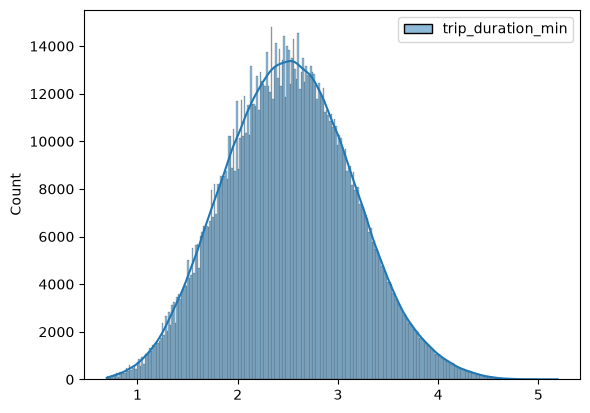

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(trans , kde=True)